# Task 1: Exploring and Visualizing the Iris Dataset

## Introduction
The Iris dataset is one of the most famous datasets in machine learning.
It contains measurements of 150 iris flowers from 3 different species.

## Problem Statement
We will load, inspect, and visualize this dataset to understand
the relationship between variables and the distribution of data.

## Dataset Description
- 150 rows, 5 columns
- Features: sepal_length, sepal_width, petal_length, petal_width
- Target: species (setosa, versicolor, virginica)

In [12]:
# Import all required libraries
import pandas as pd           # For data loading and manipulation
import matplotlib.pyplot as plt  # For creating plots
import seaborn as sns          # For beautiful statistical plots

# makes plots look nicer
sns.set_theme(style="whitegrid")
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [4]:
# Load the Iris dataset directly from seaborn's built-in datasets
df = sns.load_dataset('iris')



In [5]:
# 1. Shape: tells you (rows, columns)
print("Dataset Shape:", df.shape)

# 2. Column names
print("\nColumn Names:", df.columns.tolist())

# 3. First 5 rows
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (150, 5)

Column Names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

First 5 rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [6]:
# Statistical summary (mean, min, max, std deviation etc.)
print("Statistical Summary:")
df.describe()

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Data types of each column
print("\nData Types:")
print(df.dtypes)

# Count of each species
print("\nSpecies Count:")
print(df['species'].value_counts())

Statistical Summary:

Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Data Types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

Species Count:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


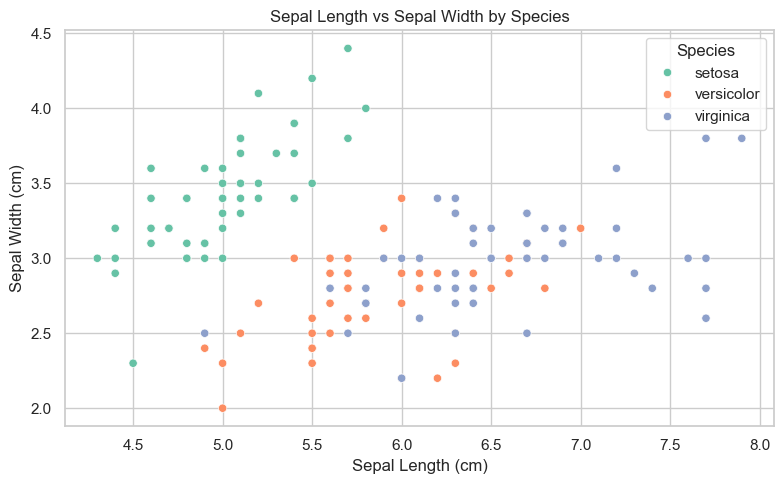

In [7]:
# SCATTER PLOT: Relationship between sepal length and sepal width
# Purpose: See if there's a pattern between two numerical variables

plt.figure(figsize=(8, 5))  # Set figure size (width, height in inches)

sns.scatterplot(
    data=df,
    x='sepal_length',    # X-axis variable
    y='sepal_width',     # Y-axis variable
    hue='species',       # Color points by species
    palette='Set2'       # Color palette
)

plt.title('Sepal Length vs Sepal Width by Species')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend(title='Species')
plt.tight_layout()
plt.show()

# Insight: What pattern do you notice? Write it in a markdown cell below!

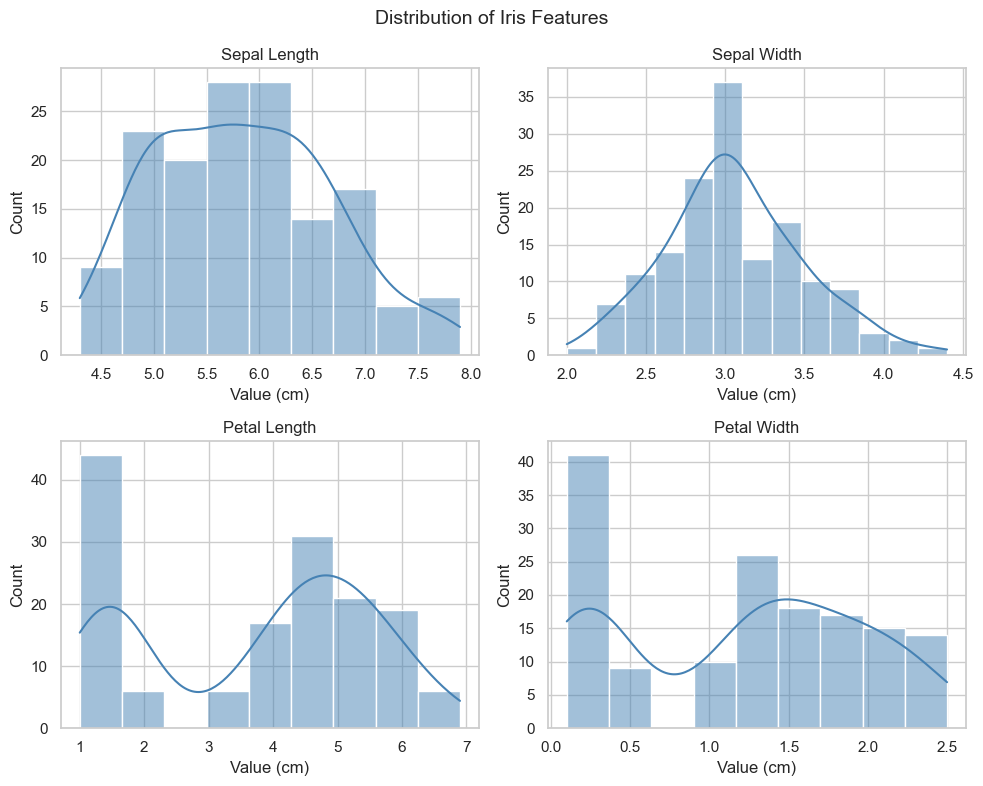

In [8]:
# HISTOGRAM: Distribution of each numerical feature
# Purpose: See how data values are spread — is it normal? skewed?

fig, axes = plt.subplots(2, 2, figsize=(10, 8))  # 2x2 grid of subplots
fig.suptitle('Distribution of Iris Features', fontsize=14)

features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

for i, feature in enumerate(features):
    ax = axes[i // 2][i % 2]  # Pick the correct subplot
    sns.histplot(df[feature], kde=True, ax=ax, color='steelblue')
    ax.set_title(feature.replace('_', ' ').title())
    ax.set_xlabel('Value (cm)')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

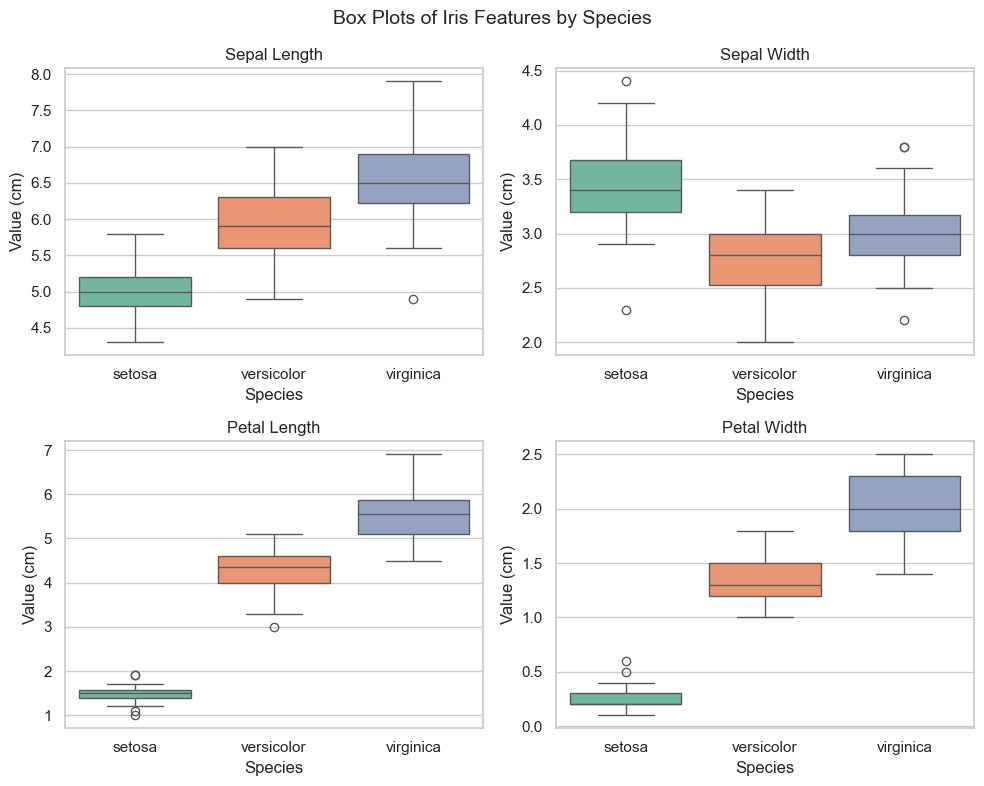

In [11]:
# BOX PLOT: Spread and outliers for each feature by species
# Purpose: Detect outliers and compare spread across categories

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle('Box Plots of Iris Features by Species', fontsize=14)

for i, feature in enumerate(features):
    ax = axes[i // 2][i % 2]
    sns.boxplot(data=df, x='species', y=feature, hue='species', palette='Set2', legend=False, ax=ax)
    ax.set_title(feature.replace('_', ' ').title())
    ax.set_xlabel('Species')
    ax.set_ylabel('Value (cm)')

plt.tight_layout()
plt.show()
# How to read a box plot:
# - Box = 25th to 75th percentile (middle 50% of data)
# - Line in box = median
# - Dots outside whiskers = outliers

# conclusion

# Key Insights:

# Scatter plot:
              Setosa forms an isolated cluster — fully separable from Versicolor and Virginica based on petal measurements alone. The other two species overlap slightly.
# Histograms: 
         Petal length and width show two distinct peaks across all species. This separation was invisible in raw summary statistics, proving why visualisation matters.
# Box plots:
           Setosa has the smallest petals with very low variance (median petal length ≈ 1.5 cm vs. 4.3 cm for Virginica). 3 outliers detected in Setosa's sepal width.

#What I Learned:

1.Inspecting data with .shape, .dtypes, and .describe() gives only a starting point — charts reveal what numbers hide.
2.Scatter plots show separability, histograms show distribution shape, and box plots expose spread and outliers — each adds a different layer of understanding.
3.EDA must always come before building a model.